# Phan Tich Cam Xuc Da Khia Canh (ABSA) - PhoBERT v5
Fine-tune `vinai/phobert-base-v2` cho bai toan ABSA voi kien truc 2-stage cho aspect head.

**Cap nhat v5 (clean-only, khong dung oversampling data-level):**
- Per-class Focal Gamma: sentiment neutral gamma=1.0, pos/neg gamma=2.5 -> giam over-predict Trung lap
- Supervised Contrastive Loss (SCL, weight=0.15) -> tang separability embedding Trung lap
- Sentiment neutral class weight duoc cap o 1.0 -> tranh khuech dai qua muc


## 1. Cài đặt thư viện

## 1.1 Luu y truoc khi chay notebook

- Neu moi truong chua co `iterative-stratification`, notebook se fallback sang split theo `sentiment_llm`.
- Neu muon split da nhan tot hon, cai them package nay truoc khi chay notebook.


## 2. Import

import các thư viện chính cho train, đánh giá và xử lý dữ liệu.

In [7]:
import os, sys, shutil, warnings
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix,
)

try:
    from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
    HAS_ITERSTRAT = True
except ImportError:
    HAS_ITERSTRAT = False
    print('[WARN] iterstrat not available, falling back to single-label stratify.')

from transformers import (
    AutoTokenizer, RobertaModel, RobertaPreTrainedModel,
    RobertaConfig, Trainer, TrainingArguments,
)
from transformers.modeling_outputs import SequenceClassifierOutput
from datasets import Dataset
from torch.utils.data import DataLoader, WeightedRandomSampler

warnings.filterwarnings('ignore')


[WARN] iterstrat not available, falling back to single-label stratify.


## 3. Cấu hình

xác định thiết bị chạy mô hình và in ra CPU/GPU hiện tại.

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Thiết bị:', device)


Thiết bị: cuda


khai báo hyperparameter và cấu hình loss dùng chung cho notebook.

In [9]:
# ?? Hyperparameters ?????????????????????????????????????????????
MODEL_NAME    = 'vinai/phobert-base-v2'
MAX_LENGTH    = 128
BATCH_SIZE    = 16
EPOCHS        = 7
LEARNING_RATE = 2e-5

# ?? Loss config ?????????????????????????????????????????????????
BASE_FOCAL_GAMMA = 2.0
CLASS_BALANCED_BETA   = 0.999
ASPECT_ABSENT_WEIGHT_SCALE = 0.2
ABSENT_ASPECT_CLASS   = 3

# ?? Task loss weights ????????????????????????????????????????????
DEFAULT_SENTIMENT_LOSS_WEIGHT = 0.5
DEFAULT_ASPECT_LOSS_WEIGHT    = 0.5

# ?? 2-stage aspect loss weights ??????????????????????????????????
STAGE1_LOSS_WEIGHT = 0.25   # presence detection
STAGE2_LOSS_WEIGHT = 0.75   # sentiment classification

# ?? Improved Focal config ????????????????????????????????????????
IMPROVED_FOCAL_SENTIMENT_SMOOTHING  = 0.05
IMPROVED_FOCAL_ASPECT_SMOOTHING     = 0.10
IMPROVED_FOCAL_ASPECT_GAMMA_PRESENT = 2.5
IMPROVED_FOCAL_ASPECT_GAMMA_ABSENT  = 1.0
IMPROVED_FOCAL_IGNORE_EASY_ABSENT   = True
IMPROVED_FOCAL_IGNORE_THRESHOLD     = 0.5

# ?? Balanced sampling config ????????????????????????????????????
SAMPLER_TEMPERATURE = 0.5
SAMPLER_WEIGHT_CAP = 4.0


định nghĩa nhãn sentiment, nhãn aspect và danh sách cột mục tiêu.

In [10]:
SENTIMENT_LABELS = {0: 'Tiêu cực', 1: 'Trung lập', 2: 'Tích cực'}
ASPECT_LABELS    = {0: 'Tiêu cực', 1: 'Trung lập', 2: 'Tích cực', 3: 'Không nhắc đến'}
ASPECT_COLS      = ['as_content', 'as_physical', 'as_price', 'as_packaging', 'as_delivery', 'as_service']
TARGET_COLS      = ['sentiment_llm'] + ASPECT_COLS


## 4. Nạp và chuẩn bị dữ liệu

tự động tìm đường dẫn train/test theo môi trường Kaggle hoặc local.

In [11]:
DATA_ROOT_CANDIDATES = [
    Path('/kaggle/input/datasets/nguynvntnpht/vietnamese-book-review-absa-clean-data'),
    Path('/kaggle/input/tiki-book-reviews'),
]
DATA_ROOT = next((p for p in DATA_ROOT_CANDIDATES if (p / 'train_clean.json').exists()),
                 Path('.'))
TRAIN_PATH = DATA_ROOT / 'train_clean.json'
TEST_PATH  = DATA_ROOT / 'test_clean.json'



chuẩn hóa DataFrame đầu vào, lọc text rỗng và đồng nhất schema.

In [12]:
def prepare_df(df: pd.DataFrame) -> pd.DataFrame:
    text_col = 'text' if 'text' in df.columns else 'content'
    df = df[[text_col] + TARGET_COLS].dropna(subset=[text_col, 'sentiment_llm']).copy()
    df = df.rename(columns={text_col: 'text'})
    df['text'] = df['text'].astype(str).str.strip()
    df = df[df['text'].ne('')]
    df['sentiment_llm'] = pd.to_numeric(df['sentiment_llm'], errors='coerce').astype('Int64')
    df = df.dropna(subset=['sentiment_llm'])
    df['sentiment_llm'] = df['sentiment_llm'].astype(int)
    df = df[df['sentiment_llm'].isin([0, 1, 2])]
    for col in ASPECT_COLS:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(3).astype(int)
        df[col] = df[col].apply(lambda x: x if x in [0, 1, 2, 3] else 3)
    return df.reset_index(drop=True)

full_train_df = prepare_df(pd.read_json(TRAIN_PATH))
test_df       = prepare_df(pd.read_json(TEST_PATH))
print(f'full_train_df: {len(full_train_df):,} | test_df: {len(test_df):,}')


full_train_df: 10,697 | test_df: 2,676


chia train/val theo multilabel stratified để giữ phân phối nhãn ổn định.

In [13]:
# Train / Val split — multilabel stratified để giữ phân phối đồng đều
if HAS_ITERSTRAT:
    msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
    train_idx, val_idx = next(msss.split(full_train_df, full_train_df[TARGET_COLS].values))
    train_df = full_train_df.iloc[train_idx].reset_index(drop=True)
    val_df   = full_train_df.iloc[val_idx].reset_index(drop=True)
else:
    train_df, val_df = train_test_split(
        full_train_df, test_size=0.15, random_state=42,
        stratify=full_train_df['sentiment_llm']
    )
    train_df = train_df.reset_index(drop=True)
    val_df   = val_df.reset_index(drop=True)

print(f'Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')
print('\nPhân phối sentiment (train):')
print(train_df['sentiment_llm'].value_counts().sort_index().rename(index=SENTIMENT_LABELS))


Train: 9,092 | Val: 1,605 | Test: 2,676

Phân phối sentiment (train):
sentiment_llm
Tiêu cực     4768
Trung lập    1482
Tích cực     2842
Name: count, dtype: int64


## 5. Chuan bi tap du lieu huan luyen


ghi chú rằng notebook đã bỏ oversampling ở mức dữ liệu.

In [14]:
# Notebook nay da bo data-level oversampling.
# Neu can can bang hon, se dung sampler on-the-fly theo phan phoi nhan.


tạo biến thể train hiện tại và in nhanh phân bố sentiment.

In [15]:
train_variants = {
    'clean': train_df.copy().reset_index(drop=True),
}

for name, df in train_variants.items():
    print(f'{name}: {len(df):,} rows | sentiment: {dict(df["sentiment_llm"].value_counts().sort_index())}')

clean_train_df = train_variants['clean']


clean: 9,092 rows | sentiment: {0: np.int64(4768), 1: np.int64(1482), 2: np.int64(2842)}


## 6. Class Weights

tính class-balanced weights từ phân phối nhãn gốc.

In [16]:
def compute_class_balanced_weights(labels, classes, beta=0.999, normalize=True, cap=None):
    values = np.asarray(labels)
    counts = {c: int((values == c).sum()) for c in classes}
    weights = []
    for c in classes:
        n = counts.get(c, 0)
        w = (1 - beta) / (1 - beta**n) if n > 0 else 0.0
        if cap is not None:
            w = min(w, cap)
        weights.append(w)
    weights = np.array(weights, dtype=float)
    # Normalize theo max để cap=1.0 giữ nguyên hiệu lực
    if normalize and weights.max() > 0:
        weights /= weights.max()
    return weights

def downweight_absent(weights, absent_class=3, scale=ASPECT_ABSENT_WEIGHT_SCALE):
    w = weights.copy()
    if len(w) > absent_class and w[absent_class] > 0:
        w[absent_class] *= scale
    if w.max() > 0:
        w /= w[w > 0].mean()
    return w


sinh trọng số sentiment, gồm bản thường và bản cap trung lập.

In [17]:
# Sentiment weights
cb_sent_weights = compute_class_balanced_weights(
    clean_train_df['sentiment_llm'].values, classes=[0, 1, 2], beta=CLASS_BALANCED_BETA
)

# neutral_capped: cap trung lập ≤ 1.0 trước khi normalize
cb_sent_weights_neutral_capped = compute_class_balanced_weights(
    clean_train_df['sentiment_llm'].values, classes=[0, 1, 2], beta=CLASS_BALANCED_BETA,
    cap=1.0,
)

# Aspect weights (class_balanced + down-weight absent)
cb_aspect_weights = {}
for col in ASPECT_COLS:
    w = compute_class_balanced_weights(clean_train_df[col].values, classes=[0,1,2,3])
    cb_aspect_weights[col] = downweight_absent(w)

# Tensors — chỉ giữ sentiment (aspect dùng presence/stage2 tensors riêng)
sent_weight_tensors = {
    'class_balanced': torch.tensor(cb_sent_weights, dtype=torch.float),
    'neutral_capped': torch.tensor(cb_sent_weights_neutral_capped, dtype=torch.float),
}

print('Sentiment weights (class_balanced):',
      {SENTIMENT_LABELS[i]: round(float(w), 3) for i, w in enumerate(cb_sent_weights)})
print('Sentiment weights (neutral_capped) :',
      {SENTIMENT_LABELS[i]: round(float(w), 3) for i, w in enumerate(cb_sent_weights_neutral_capped)})


def build_joint_label_sampler(frame: pd.DataFrame, temperature: float = SAMPLER_TEMPERATURE):
    aspect_values = frame[ASPECT_COLS].apply(pd.to_numeric, errors='coerce').fillna(3).astype(int)
    present_count = aspect_values.ne(3).sum(axis=1).clip(upper=len(ASPECT_COLS)).astype(int)
    joint_group = (
        'sent=' + frame['sentiment_llm'].astype(str)
        + '|present=' + present_count.astype(str)
    )
    counts = joint_group.value_counts()
    sample_weights = joint_group.map(lambda g: counts[g] ** (-temperature)).astype(float)
    sample_weights = sample_weights / sample_weights.mean()
    sample_weights = sample_weights.clip(upper=SAMPLER_WEIGHT_CAP)
    sample_weights = sample_weights / sample_weights.mean()

    sampler = WeightedRandomSampler(
        weights=torch.as_tensor(sample_weights.values, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True,
    )

    summary = (
        pd.DataFrame({'group': joint_group, 'weight': sample_weights})
        .groupby('group', as_index=False)
        .agg(count=('group', 'size'), avg_weight=('weight', 'mean'))
        .sort_values(['count', 'group'], ascending=[False, True])
        .reset_index(drop=True)
    )
    return sampler, summary


Sentiment weights (class_balanced): {'Tiêu cực': 0.78, 'Trung lập': 1.0, 'Tích cực': 0.821}
Sentiment weights (neutral_capped) : {'Tiêu cực': 0.78, 'Trung lập': 1.0, 'Tích cực': 0.821}


khai báo trọng số presence cho từng aspect ở stage 1.

In [18]:
# Per-aspect presence weights (stage-1: binary absent/present)
PRESENCE_WEIGHTS = {
    'as_content':   [0.5355, 1.4645],
    'as_physical':  [0.6821, 1.3179],
    'as_price':     [0.1948, 1.8052],
    'as_packaging': [0.3390, 1.6610],
    'as_delivery':  [0.4986, 1.5014],
    'as_service':   [0.0565, 1.9435],
}

# Per-aspect stage-2 weights (3-class sentiment, present samples only)
STAGE2_WEIGHTS = {
    'as_content':   [0.5347, 2.1387, 0.3266],
    'as_physical':  [0.4331, 1.9841, 0.5829],
    'as_price':     [1.7307, 0.2664, 1.0029],
    'as_packaging': [0.2651, 2.5047, 0.2302],
    'as_delivery':  [1.4604, 1.1389, 0.4007],
    'as_service':   [1.9428, 0.6296, 0.4277],
}

presence_weight_tensors = {col: torch.tensor(w, dtype=torch.float) for col, w in PRESENCE_WEIGHTS.items()}
stage2_weight_tensors   = {col: torch.tensor(w, dtype=torch.float) for col, w in STAGE2_WEIGHTS.items()}



## 7. Kiến trúc Model (2-Stage Aspect Head)

định nghĩa kiến trúc ABSAModel với head sentiment, presence và aspect sentiment.

In [19]:
class ABSAModel(RobertaPreTrainedModel):
    """
    PhoBERT với 3 loại head:
      - sentiment_head       : (B, 3) — cảm xúc tổng thể
      - presence_heads [×6]  : (B, 2) — có/không nhắc đến từng aspect
      - aspect_sentiment_heads [×6] : (B, 3) — cảm xúc từng aspect (chỉ khi present)

    Logits layout: [sent(3) | pres_0..5(2) | asp_sent_0..5(3)]
    """
    config_class = RobertaConfig

    def __init__(self, config):
        super().__init__(config)
        self.roberta = RobertaModel(config, add_pooling_layer=False)
        drop_p = getattr(config, 'classifier_dropout', None) or getattr(config, 'hidden_dropout_prob', 0.1)
        self.dropout = nn.Dropout(drop_p)
        n = len(ASPECT_COLS)
        self.sentiment_head        = nn.Linear(config.hidden_size, 3)
        self.presence_heads        = nn.ModuleList([nn.Linear(config.hidden_size, 2) for _ in range(n)])
        self.aspect_sentiment_heads = nn.ModuleList([nn.Linear(config.hidden_size, 3) for _ in range(n)])
        self.post_init()

    @classmethod
    def _can_set_experts_implementation(cls):
        return False

    def forward(self, input_ids=None, attention_mask=None, labels=None, **kwargs):
        outputs = self.roberta(input_ids, attention_mask=attention_mask)
        cls = self.dropout(outputs.last_hidden_state[:, 0, :])
        self._last_cls = cls

        sent_logits     = self.sentiment_head(cls)
        pres_logits     = torch.stack([h(cls) for h in self.presence_heads], dim=1)
        asp_sent_logits = torch.stack([h(cls) for h in self.aspect_sentiment_heads], dim=1)

        logits = torch.cat([
            sent_logits,
            pres_logits.view(cls.size(0), -1),
            asp_sent_logits.view(cls.size(0), -1),
        ], dim=-1)
        return SequenceClassifierOutput(logits=logits)


N_ASPECTS    = len(ASPECT_COLS)
SENT_DIM     = 3
PRES_DIM     = 2
ASP_SENT_DIM = 3

def parse_logits(logits):
    s = SENT_DIM
    p = N_ASPECTS * PRES_DIM
    return logits[:, :s], logits[:, s:s+p].view(-1, N_ASPECTS, PRES_DIM), logits[:, s+p:].view(-1, N_ASPECTS, ASP_SENT_DIM)


## 8. Hàm Loss

cài hàm smoothing target và chọn gamma theo lớp.

In [20]:
def build_smoothed_targets(logits, targets, smoothing):
    n_cls = logits.size(-1)
    with torch.no_grad():
        t = torch.full_like(logits, smoothing / n_cls)
        t.scatter_(1, targets.unsqueeze(1), 1.0 - smoothing + smoothing / n_cls)
    return t

def resolve_gamma_per_sample(targets, logits, gamma, gamma_by_class):
    if gamma_by_class is None:
        return torch.full((targets.size(0),), float(gamma), dtype=logits.dtype, device=logits.device)
    return torch.as_tensor(gamma_by_class, dtype=logits.dtype, device=logits.device)[targets]

def filter_easy_absent(loss, targets, true_probs, ignore_easy_absent, ignore_threshold, absent_class):
    if not (ignore_easy_absent and absent_class is not None and ignore_threshold is not None):
        return loss.mean()
    keep = ~((targets == absent_class) & (true_probs > ignore_threshold))
    return loss[keep].mean() if keep.any() else loss.mean()

def improved_focal_loss(logits, targets, *, gamma=2.0, alpha=None, smoothing=0.0,
                         gamma_by_class=None, ignore_easy_absent=False,
                         ignore_threshold=None, absent_class=None):
    smoothed = build_smoothed_targets(logits, targets, smoothing)
    log_probs  = F.log_softmax(logits, dim=-1)
    true_probs = log_probs.exp().gather(1, targets.unsqueeze(1)).squeeze(1).clamp(1e-6, 1.0)
    focal_gamma = resolve_gamma_per_sample(targets, logits, gamma, gamma_by_class)
    loss = ((1 - true_probs).pow(focal_gamma)) * (-(smoothed * log_probs).sum(dim=-1))
    if alpha is not None:
        loss = loss * alpha.to(logits.device)[targets]
    return filter_easy_absent(loss, targets, true_probs, ignore_easy_absent, ignore_threshold, absent_class)

def asymmetric_focal_loss(logits, targets, *, gamma_neg=4.0, gamma_pos=1.0, clip=0.05, class_weights=None):
    probs = torch.softmax(logits, dim=-1)
    log_p = torch.log(probs.clamp(min=1e-8))
    C     = logits.size(-1)
    oh    = F.one_hot(targets, C).float().to(logits.device)
    p_pos = (probs * oh).sum(-1)
    loss_p = -(1 - p_pos).pow(gamma_pos) * (log_p * oh).sum(-1)
    pn_s  = (probs * (1 - oh) + clip).clamp(max=1.0)
    l1mp  = torch.log((1.0 - probs * (1 - oh)).clamp(min=1e-8))
    loss_n = -(pn_s.pow(gamma_neg) * (1 - oh) * l1mp).sum(-1)
    loss  = loss_p + loss_n
    if class_weights is not None:
        loss = loss * class_weights.to(logits.device)[targets]
    return loss.mean()


định nghĩa supervised contrastive loss để kéo embedding cùng lớp gần nhau.

In [21]:
class SupervisedContrastiveLoss(nn.Module):
    """Kéo CLS embeddings cùng class lại gần nhau → tăng separability Trung lập."""
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        B = features.size(0)
        if B < 2:
            return features.new_tensor(0.0)
        feat = F.normalize(features, dim=-1)
        sim  = feat @ feat.T / self.temperature
        pos  = (labels.unsqueeze(0) == labels.unsqueeze(1)).float()
        pos.fill_diagonal_(0.0)
        denom = torch.log(
            (torch.exp(sim) * (1 - torch.eye(B, device=sim.device))).sum(-1).clamp(min=1e-8)
        )
        loss = -((pos * sim).sum(-1) / pos.sum(-1).clamp(min=1) - denom)
        return loss.mean()

supervised_contrastive = SupervisedContrastiveLoss(temperature=0.07)


gom các kiểu loss gồm CE, focal và các biến thể có trọng số.

In [22]:
def compute_label_loss(logits, targets, *, loss_name='ce', class_weights=None,
                        gamma=2.0, alpha=None, focal_params=None):
    fp = dict(focal_params or {})
    if loss_name == 'ce':
        return F.cross_entropy(logits, targets, weight=class_weights)
    if loss_name == 'improved_focal':
        return improved_focal_loss(
            logits, targets,
            gamma=fp.get('gamma', gamma),
            alpha=alpha,
            smoothing=fp.get('smoothing', 0.0),
            gamma_by_class=fp.get('gamma_by_class'),
            ignore_easy_absent=fp.get('ignore_easy_absent', False),
            ignore_threshold=fp.get('ignore_threshold'),
            absent_class=fp.get('absent_class'),
        )
    if loss_name == 'asl':
        return asymmetric_focal_loss(
            logits, targets,
            gamma_neg=fp.get('asl_gamma_neg', 4.0),
            gamma_pos=fp.get('asl_gamma_pos', 1.0),
            clip=fp.get('asl_clip', 0.05),
            class_weights=class_weights,
        )
    raise ValueError(f'Unsupported loss_name: {loss_name!r}')


## 9. Multi-Task Trainer

chuẩn hóa trọng số giữa loss sentiment và loss aspect.

In [23]:
def normalize_task_weights(sw, aw):
    total = float(sw) + float(aw)
    return float(sw) / total, float(aw) / total

def compute_sentiment_loss(trainer, logits, labels):
    sent_logits, _, _ = parse_logits(logits)
    w = trainer.sent_weights.to(logits.device) if trainer.use_class_weights and trainer.sent_weights is not None else None
    # improved_focal_loss d?ng alpha ch? kh?ng d?ng class_weights
    # ? truy?n sent_weights tr?c ti?p l?m alpha ?? neutral_capped c? hi?u l?c
    alpha = w if trainer.loss_name == 'improved_focal' else None
    fp = dict(trainer.focal_config.get('sentiment') or {})
    return compute_label_loss(sent_logits, labels[:, 0],
                              loss_name=trainer.loss_name,
                              class_weights=w, gamma=trainer.focal_gamma,
                              alpha=alpha, focal_params=fp)

def compute_aspect_loss(trainer, logits, labels):
    _, pres_logits, asp_sent_logits = parse_logits(logits)
    aspect_labels = labels[:, 1:]
    s1_losses, s2_losses = [], []
    for i, col in enumerate(ASPECT_COLS):
        asp_label  = aspect_labels[:, i]
        pres_label = (asp_label != 3).long()
        pres_w     = presence_weight_tensors[col].to(logits.device)
        s1_losses.append(F.cross_entropy(pres_logits[:, i, :], pres_label, weight=pres_w))
        present_mask = asp_label != 3
        if present_mask.any():
            s2_logits = asp_sent_logits[:, i, :][present_mask]
            s2_labels = asp_label[present_mask]
            s2_w      = stage2_weight_tensors[col].to(logits.device)
            fp = dict(trainer.focal_config.get('aspect', {}))
            if 'gamma_by_class' in fp:
                fp['gamma_by_class'] = fp['gamma_by_class'][:3]
            for key in ('ignore_easy_absent', 'ignore_threshold', 'absent_class'):
                fp.pop(key, None)
            s2_losses.append(compute_label_loss(
                s2_logits, s2_labels,
                loss_name=trainer.loss_name,
                class_weights=s2_w, gamma=trainer.focal_gamma,
                focal_params=fp,
            ))
    loss_s1 = sum(s1_losses) / len(s1_losses)
    loss_s2 = sum(s2_losses) / len(s2_losses) if s2_losses else logits.new_zeros(())
    return STAGE1_LOSS_WEIGHT * loss_s1 + STAGE2_LOSS_WEIGHT * loss_s2


class ABSAMultiTaskTrainer(Trainer):
    def __init__(self, *args, sent_weights=None, loss_name='ce',
                 use_class_weights=False, focal_gamma=2.0,
                 focal_config=None, sentiment_loss_weight=0.5,
                 aspect_loss_weight=0.5, scl_weight=0.0,
                 train_sampler=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.sent_weights   = sent_weights
        self.loss_name      = loss_name
        self.use_class_weights = use_class_weights
        self.focal_gamma    = focal_gamma
        self.focal_config   = focal_config or {}
        self.sentiment_loss_weight, self.aspect_loss_weight = normalize_task_weights(
            sentiment_loss_weight, aspect_loss_weight
        )
        self.scl_weight = scl_weight
        self.train_sampler = train_sampler

    def get_train_dataloader(self):
        if self.train_sampler is None:
            return super().get_train_dataloader()
        if self.train_dataset is None:
            raise ValueError('Trainer requires a train_dataset when train_sampler is set.')
        return DataLoader(
            self.train_dataset,
            batch_size=self.args.train_batch_size,
            sampler=self.train_sampler,
            collate_fn=self.data_collator,
            drop_last=self.args.dataloader_drop_last,
            num_workers=self.args.dataloader_num_workers,
            pin_memory=self.args.dataloader_pin_memory,
        )

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        logits  = outputs.logits

        loss = (self.sentiment_loss_weight * compute_sentiment_loss(self, logits, labels)
                + self.aspect_loss_weight  * compute_aspect_loss(self, logits, labels))

        if self.scl_weight > 0 and model.training:
            cls_vec = getattr(model, '_last_cls', None)
            if cls_vec is not None:
                loss = loss + self.scl_weight * supervised_contrastive(cls_vec, labels[:, 0])

        return (loss, outputs) if return_outputs else loss


## 10. Metrics

tính metric đánh giá cho sentiment và từng aspect.

In [24]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    s = SENT_DIM
    p = N_ASPECTS * PRES_DIM

    pred_sent     = np.argmax(logits[:, :s], axis=-1)
    pred_presence = np.argmax(logits[:, s:s+p].reshape(-1, N_ASPECTS, PRES_DIM), axis=-1)
    pred_asp_sent = np.argmax(logits[:, s+p:].reshape(-1, N_ASPECTS, ASP_SENT_DIM), axis=-1)

    true_sent    = labels[:, 0]
    true_aspects = labels[:, 1:]
    pred_aspects = np.where(pred_presence == 0, 3, pred_asp_sent)

    _, _, f1_sent, _ = precision_recall_fscore_support(
        true_sent, pred_sent, labels=[0,1,2], average='macro', zero_division=0)

    present_mask = true_aspects.flatten() != 3
    f1_asp_present = 0.0
    if present_mask.any():
        _, _, f1_asp_present, _ = precision_recall_fscore_support(
            true_aspects.flatten()[present_mask],
            pred_aspects.flatten()[present_mask],
            labels=[0,1,2], average='macro', zero_division=0)

    _, _, f1_asp_all, _ = precision_recall_fscore_support(
        true_aspects.flatten(), pred_aspects.flatten(),
        labels=[0,1,2,3], average='macro', zero_division=0)

    asp_f1s = {}
    for i, col in enumerate(ASPECT_COLS):
        mask = true_aspects[:, i] != 3
        if mask.any():
            _, _, f1_i, _ = precision_recall_fscore_support(
                true_aspects[:, i][mask], pred_aspects[:, i][mask],
                labels=[0,1,2], average='macro', zero_division=0)
        else:
            f1_i = 0.0
        asp_f1s[f'f1_{col}'] = round(f1_i, 4)

    f1_combined = 0.6 * f1_sent + 0.4 * f1_asp_present
    acc = accuracy_score(
        np.concatenate([true_sent, true_aspects.flatten()]),
        np.concatenate([pred_sent, pred_aspects.flatten()]))

    return {
        'f1_sentiment':      round(f1_sent, 4),
        'f1_aspect_all':     round(f1_asp_all, 4),
        'f1_aspect_present': round(f1_asp_present, 4),
        'f1_combined':       round(f1_combined, 4),
        'accuracy':          round(acc, 4),
        **asp_f1s,
    }


## 11. Tokenization

nạp tokenizer PhoBERT và chuyển DataFrame sang HuggingFace Dataset.

In [25]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_frame(frame: pd.DataFrame) -> Dataset:
    def _tokenize(examples):
        enc = tokenizer(examples['text'], padding='max_length',
                        truncation=True, max_length=MAX_LENGTH)
        enc['labels'] = [[examples[col][i] for col in TARGET_COLS]
                         for i in range(len(examples['text']))]
        return enc
    ds = Dataset.from_pandas(frame.reset_index(drop=True)).map(
        _tokenize, batched=True, remove_columns=['text'] + TARGET_COLS)
    ds.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
    return ds

val_encoded  = tokenize_frame(val_df)
test_encoded = tokenize_frame(test_df)
print('Val encoded:', len(val_encoded), '| Test encoded:', len(test_encoded))


config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/1605 [00:00<?, ? examples/s]

Map:   0%|          | 0/2676 [00:00<?, ? examples/s]

Val encoded: 1605 | Test encoded: 2676


In [ ]:
# [added] tokenization preview
from IPython.display import display

def show_tokenized_sample(df, idx=0, max_rows=60):
    row = df.iloc[idx]
    text = row['text']

    enc = tokenizer(
        text,
        truncation=True,
        max_length=MAX_LENGTH,
        padding='max_length',
    )
    tokens = tokenizer.convert_ids_to_tokens(enc['input_ids'])
    valid_len = int(sum(enc['attention_mask']))
    decoded = tokenizer.decode(enc['input_ids'], skip_special_tokens=True)

    print('V?n b?n g?c:')
    print(text)
    print('
V?n b?n sau decode:')
    print(decoded)
    print(f'
S? token (bao g?m special tokens): {valid_len}')

    preview = pd.DataFrame({
        'token': tokens[:valid_len],
        'input_id': enc['input_ids'][:valid_len],
        'attention_mask': enc['attention_mask'][:valid_len],
    })
    display(preview.head(max_rows))

show_tokenized_sample(train_df, idx=0)


## 12. Cấu hình huấn luyện và Experiments

khai báo TrainingArguments dùng chung cho các experiment.

In [26]:
EXP_TRAIN_EPOCHS = EPOCHS
USE_FP16 = torch.cuda.is_available()

def build_training_args(output_dir: str) -> TrainingArguments:
    kwargs = dict(
        output_dir=output_dir,
        num_train_epochs=EXP_TRAIN_EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE * 2,
        gradient_accumulation_steps=2,
        learning_rate=LEARNING_RATE,
        lr_scheduler_type='cosine',
        warmup_ratio=0.1,
        weight_decay=0.05,
        max_grad_norm=1.0,
        fp16=USE_FP16,
        logging_dir=str(Path(output_dir) / 'logs'),
        logging_steps=100,
        save_strategy='epoch',
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model='f1_combined',
        greater_is_better=True,
        report_to='none',
    )
    if 'eval_strategy' in TrainingArguments.__init__.__code__.co_varnames:
        kwargs['eval_strategy'] = 'epoch'
    else:
        kwargs['evaluation_strategy'] = 'epoch'
    return TrainingArguments(**kwargs)


định nghĩa cấu hình focal loss dùng chung cho các experiment.

In [27]:
# Focal config chia sẻ cho các experiment
FOCAL_CONFIG_STANDARD = {
    'sentiment': {
        'gamma':    BASE_FOCAL_GAMMA,
        'smoothing': IMPROVED_FOCAL_SENTIMENT_SMOOTHING,
    },
    'aspect': {
        'gamma':    BASE_FOCAL_GAMMA,
        'smoothing': IMPROVED_FOCAL_ASPECT_SMOOTHING,
        'gamma_by_class': [
            IMPROVED_FOCAL_ASPECT_GAMMA_PRESENT,
            IMPROVED_FOCAL_ASPECT_GAMMA_PRESENT,
            IMPROVED_FOCAL_ASPECT_GAMMA_PRESENT,
            IMPROVED_FOCAL_ASPECT_GAMMA_ABSENT,
        ],
        'ignore_easy_absent': IMPROVED_FOCAL_IGNORE_EASY_ABSENT,
        'ignore_threshold':   IMPROVED_FOCAL_IGNORE_THRESHOLD,
        'absent_class':       ABSENT_ASPECT_CLASS,
    },
}

# Focal config cải tiến Trung lập:
#   sentiment neutral γ=1.0 (thay vì 2.0) → giảm focal suppression → giảm over-predict Trung lập
FOCAL_CONFIG_NEUTRAL = {
    'sentiment': {
        'gamma':          BASE_FOCAL_GAMMA,
        'smoothing':      IMPROVED_FOCAL_SENTIMENT_SMOOTHING,
        'gamma_by_class': [2.5, 1.0, 2.5],   # neutral nhận γ thấp hơn pos/neg
    },
    'aspect': FOCAL_CONFIG_STANDARD['aspect'],
}


khai báo danh sách experiment cần chạy và so sánh.

In [28]:
EXPERIMENTS = [
    # Baseline: CE thuan
    {
        'name': 'baseline',
        'train_key': 'clean',
        'loss_name': 'ce',
        'use_class_weights': False,
        'sent_weight_key': None,
        'train_sampler': None,
        'sampler_temperature': None,
        'sentiment_loss_weight': 0.5,
        'aspect_loss_weight':    0.5,
        'scl_weight': 0.0,
        'focal_config': FOCAL_CONFIG_STANDARD,
    },
    # Clean + CE + class-balanced weights
    {
        'name': 'clean_class_balanced_ce',
        'train_key': 'clean',
        'loss_name': 'ce',
        'use_class_weights': True,
        'sent_weight_key': 'class_balanced',
        'train_sampler': None,
        'sampler_temperature': None,
        'sentiment_loss_weight': 0.3,
        'aspect_loss_weight':    0.7,
        'scl_weight': 0.0,
        'focal_config': FOCAL_CONFIG_STANDARD,
    },
    # Clean + CE + joint sampler
    {
        'name': 'clean_joint_balanced_ce',
        'train_key': 'clean',
        'loss_name': 'ce',
        'use_class_weights': False,
        'sent_weight_key': None,
        'train_sampler': 'joint_balanced',
        'sampler_temperature': 0.5,
        'sentiment_loss_weight': 0.3,
        'aspect_loss_weight':    0.7,
        'scl_weight': 0.0,
        'focal_config': FOCAL_CONFIG_STANDARD,
    },
    # Clean + Improved Focal + joint sampler + class-balanced sentiment
    {
        'name': 'clean_joint_balanced_focal',
        'train_key': 'clean',
        'loss_name': 'improved_focal',
        'use_class_weights': True,
        'sent_weight_key': 'class_balanced',
        'train_sampler': 'joint_balanced',
        'sampler_temperature': 0.5,
        'sentiment_loss_weight': 0.3,
        'aspect_loss_weight':    0.7,
        'scl_weight': 0.0,
        'focal_config': FOCAL_CONFIG_STANDARD,
    },
    # Clean + Improved Focal + neutral focus + SCL + joint sampler
    {
        'name': 'clean_joint_balanced_neutral_scl',
        'train_key': 'clean',
        'loss_name': 'improved_focal',
        'use_class_weights': True,
        'sent_weight_key': 'neutral_capped',
        'train_sampler': 'joint_balanced',
        'sampler_temperature': 0.5,
        'sentiment_loss_weight': 0.3,
        'aspect_loss_weight':    0.7,
        'scl_weight': 0.15,
        'focal_config': FOCAL_CONFIG_NEUTRAL,
    },
]


## 13. Chạy Experiments

huấn luyện một experiment theo cấu hình đã khai báo.

In [29]:
def run_experiment(cfg: dict) -> dict:
    train_frame   = train_variants[cfg['train_key']]
    train_encoded = tokenize_frame(train_frame)

    model = ABSAModel.from_pretrained(MODEL_NAME).to(device)
    output_dir    = f'./absa_results/{cfg["name"]}'
    training_args = build_training_args(output_dir)

    sent_weights = None
    if cfg['use_class_weights'] and cfg.get('sent_weight_key'):
        sent_weights = sent_weight_tensors[cfg['sent_weight_key']]

    train_sampler = None
    if cfg.get('train_sampler') == 'joint_balanced':
        train_sampler, sampler_summary = build_joint_label_sampler(
            train_frame, temperature=cfg.get('sampler_temperature', SAMPLER_TEMPERATURE)
        )
        print('Joint sampler preview:')
        print(sampler_summary.head(12).to_string(index=False))

    trainer = ABSAMultiTaskTrainer(
        model=model,
        args=training_args,
        train_dataset=train_encoded,
        eval_dataset=val_encoded,
        compute_metrics=compute_metrics,
        sent_weights=sent_weights,
        loss_name=cfg['loss_name'],
        use_class_weights=cfg['use_class_weights'],
        focal_gamma=BASE_FOCAL_GAMMA,
        focal_config=cfg.get('focal_config', FOCAL_CONFIG_STANDARD),
        sentiment_loss_weight=cfg.get('sentiment_loss_weight', DEFAULT_SENTIMENT_LOSS_WEIGHT),
        aspect_loss_weight=cfg.get('aspect_loss_weight', DEFAULT_ASPECT_LOSS_WEIGHT),
        scl_weight=cfg.get('scl_weight', 0.0),
        train_sampler=train_sampler,
    )

    print()
    print(f"=== {cfg['name']} | train={len(train_frame):,} | loss={cfg['loss_name']} | scl={cfg['scl_weight']} ===")
    trainer.train()

    val_metrics = trainer.evaluate(val_encoded)
    trainer.save_model(output_dir)
    tokenizer.save_pretrained(output_dir)

    # D?n checkpoint trung gian
    del trainer
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    for ckpt in Path(output_dir).glob('checkpoint-*'):
        shutil.rmtree(ckpt, ignore_errors=True)

    return {
        'name':                 cfg['name'],
        'train_key':            cfg['train_key'],
        'train_rows':           len(train_frame),
        'loss_name':            cfg['loss_name'],
        'use_class_weights':    cfg['use_class_weights'],
        'sent_weight_key':      cfg.get('sent_weight_key'),
        'train_sampler':        cfg.get('train_sampler'),
        'sampler_temperature':  cfg.get('sampler_temperature'),
        'scl_weight':           cfg.get('scl_weight', 0.0),
        'output_dir':           output_dir,
        'focal_config':         cfg.get('focal_config', FOCAL_CONFIG_STANDARD),
        'val_metrics':          val_metrics,
    }


chạy tuần tự toàn bộ experiment và thu kết quả.

In [30]:
experiment_results = []
for cfg in EXPERIMENTS:
    experiment_results.append(run_experiment(cfg))


Map:   0%|          | 0/9092 [00:00<?, ? examples/s]

pytorch_model.bin:   0%|          | 0.00/540M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ABSAModel LOAD REPORT from: vinai/phobert-base-v2
Key                                              | Status     | 
-------------------------------------------------+------------+-
lm_head.bias                                     | UNEXPECTED | 
lm_head.dense.bias                               | UNEXPECTED | 
lm_head.dense.weight                             | UNEXPECTED | 
lm_head.layer_norm.bias                          | UNEXPECTED | 
lm_head.layer_norm.weight                        | UNEXPECTED | 
roberta.embeddings.position_ids                  | UNEXPECTED | 
aspect_sentiment_heads.{0, 1, 2, 3, 4, 5}.weight | MISSING    | 
presence_heads.{0, 1, 2, 3, 4, 5}.weight         | MISSING    | 
aspect_sentiment_heads.{0, 1, 2, 3, 4, 5}.bias   | MISSING    | 
presence_heads.{0, 1, 2, 3, 4, 5}.bias           | MISSING    | 
sentiment_head.bias                              | MISSING    | 
sentiment_head.weight                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored whe

model.safetensors:   0%|          | 0.00/540M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## 14. So sánh kết quả

tổng hợp metric của các experiment vào bảng so sánh.

In [31]:
def mv(metrics, key):
    return metrics.get(f'eval_{key}', metrics.get(key))

rows = []
for r in experiment_results:
    rows.append({
        'experiment':        r['name'],
        'train_key':         r['train_key'],
        'train_rows':        r['train_rows'],
        'loss_name':         r['loss_name'],
        'train_sampler':      r.get('train_sampler'),
        'sampler_temperature': r.get('sampler_temperature'),
        'scl_weight':        r['scl_weight'],
        'sent_weight_key':   r.get('sent_weight_key'),
        'val_f1_sentiment':  mv(r['val_metrics'], 'f1_sentiment'),
        'val_f1_aspect_present': mv(r['val_metrics'], 'f1_aspect_present'),
        'val_f1_combined':   mv(r['val_metrics'], 'f1_combined'),
        'val_accuracy':      mv(r['val_metrics'], 'accuracy'),
    })

comparison_df = pd.DataFrame(rows).sort_values('val_f1_combined', ascending=False)
display(comparison_df)

Path('experiments/reports').mkdir(parents=True, exist_ok=True)
comparison_df.to_csv('experiments/reports/experiment_summary.csv', index=False)

best_result = next(r for r in experiment_results if r['name'] == comparison_df.iloc[0]['experiment'])
print('Best experiment:', best_result['name'])


,experiment,train_key,train_rows,loss_name,train_sampler,sampler_temperature,scl_weight,sent_weight_key,val_f1_sentiment,val_f1_aspect_present,val_f1_combined,val_accuracy
3,clean_joint_balanced_focal,clean,9092,improved_focal,joint_balanced,0.5,0.00,class_balanced,0.8519,0.7854,0.8253,0.8433
4,clean_joint_balanced_neutral_scl,clean,9092,improved_focal,joint_balanced,0.5,0.15,neutral_capped,0.8369,0.7841,0.8158,0.8367
2,clean_joint_balanced_ce,clean,9092,ce,joint_balanced,0.5,0.00,None,0.8301,0.6887,0.7735,0.7408
1,clean_class_balanced_ce,clean,9092,ce,None,NaN,0.00,class_balanced,0.8390,0.6703,0.7715,0.7879
0,baseline,clean,9092,ce,None,NaN,0.00,None,0.8543,0.6142,0.7582,0.7637


Best experiment: clean_joint_balanced_focal


## 15. Đánh giá chi tiết — Best Model

nạp mô hình tốt nhất để đánh giá chi tiết trên test set.

In [32]:
best_model_dir   = Path(best_result['output_dir'])
best_model       = ABSAModel.from_pretrained(best_model_dir).to(device)
best_tokenizer   = AutoTokenizer.from_pretrained(best_model_dir)
best_sent_weights = None
if best_result['use_class_weights'] and best_result.get('sent_weight_key'):
    best_sent_weights = sent_weight_tensors[best_result['sent_weight_key']]

eval_args = build_training_args(str(best_model_dir / 'eval_only'))
best_trainer = ABSAMultiTaskTrainer(
    model=best_model,
    args=eval_args,
    eval_dataset=val_encoded,
    compute_metrics=compute_metrics,
    sent_weights=best_sent_weights,
    loss_name=best_result['loss_name'],
    use_class_weights=best_result['use_class_weights'],
    focal_gamma=BASE_FOCAL_GAMMA,
    focal_config=best_result.get('focal_config', FOCAL_CONFIG_STANDARD),
    train_sampler=None,
)

val_result  = best_trainer.evaluate(val_encoded)
test_result = best_trainer.evaluate(test_encoded)
print('Val  metrics:', val_result)
print('Test metrics:', test_result)


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Val  metrics: {'eval_loss': 0.13867296278476715, 'eval_f1_sentiment': 0.8519, 'eval_f1_aspect_all': 0.6573, 'eval_f1_aspect_present': 0.7854, 'eval_f1_combined': 0.8253, 'eval_accuracy': 0.8433, 'eval_f1_as_content': 0.6505, 'eval_f1_as_physical': 0.664, 'eval_f1_as_price': 0.6614, 'eval_f1_as_packaging': 0.5788, 'eval_f1_as_delivery': 0.8017, 'eval_f1_as_service': 0.7143, 'eval_runtime': 6.661, 'eval_samples_per_second': 240.953, 'eval_steps_per_second': 3.903}
Test metrics: {'eval_loss': 0.1403266191482544, 'eval_f1_sentiment': 0.8423, 'eval_f1_aspect_all': 0.6693, 'eval_f1_aspect_present': 0.7786, 'eval_f1_combined': 0.8168, 'eval_accuracy': 0.8508, 'eval_f1_as_content': 0.6737, 'eval_f1_as_physical': 0.6541, 'eval_f1_as_price': 0.646, 'eval_f1_as_packaging': 0.586, 'eval_f1_as_delivery': 0.8254, 'eval_f1_as_service': 0.6474, 'eval_runtime': 11.1362, 'eval_samples_per_second': 240.297, 'eval_steps_per_second': 3.771}


sinh dự đoán trên test set và chuyển logits sang nhãn cuối.

In [33]:
raw_pred, _, _ = best_trainer.predict(test_encoded)
s = SENT_DIM
p = N_ASPECTS * PRES_DIM

pred_sent     = np.argmax(raw_pred[:, :s], axis=1)
pred_presence = np.argmax(raw_pred[:, s:s+p].reshape(-1, N_ASPECTS, PRES_DIM), axis=-1)
pred_asp_sent = np.argmax(raw_pred[:, s+p:].reshape(-1, N_ASPECTS, ASP_SENT_DIM), axis=-1)
pred_asps     = np.where(pred_presence == 0, 3, pred_asp_sent)

true_sent  = test_df['sentiment_llm'].values
true_asps  = test_df[ASPECT_COLS].values

print('=== SENTIMENT TỔNG THỂ (TEST SET) ===')
print(classification_report(
    true_sent, pred_sent, labels=[0,1,2],
    target_names=['Tiêu cực', 'Trung lập', 'Tích cực'], zero_division=0))

print('=== 6 ASPECT — present only (TEST SET) ===')
present_mask = true_asps.flatten() != 3
print(classification_report(
    true_asps.flatten()[present_mask],
    pred_asps.flatten()[present_mask],
    labels=[0,1,2],
    target_names=['Tiêu cực', 'Trung lập', 'Tích cực'], zero_division=0))


=== SENTIMENT TỔNG THỂ (TEST SET) ===
              precision    recall  f1-score   support

    Tiêu cực       0.95      0.92      0.94      1402
   Trung lập       0.64      0.74      0.68       437
    Tích cực       0.92      0.89      0.91       837

    accuracy                           0.88      2676
   macro avg       0.84      0.85      0.84      2676
weighted avg       0.89      0.88      0.89      2676

=== 6 ASPECT — present only (TEST SET) ===
              precision    recall  f1-score   support

    Tiêu cực       0.86      0.82      0.84      1053
   Trung lập       0.80      0.48      0.60       601
    Tích cực       0.89      0.89      0.89      1443

   micro avg       0.87      0.79      0.83      3097
   macro avg       0.85      0.73      0.78      3097
weighted avg       0.86      0.79      0.82      3097



## 16. Confusion Matrices

vẽ confusion matrix cho sentiment và 6 aspect.

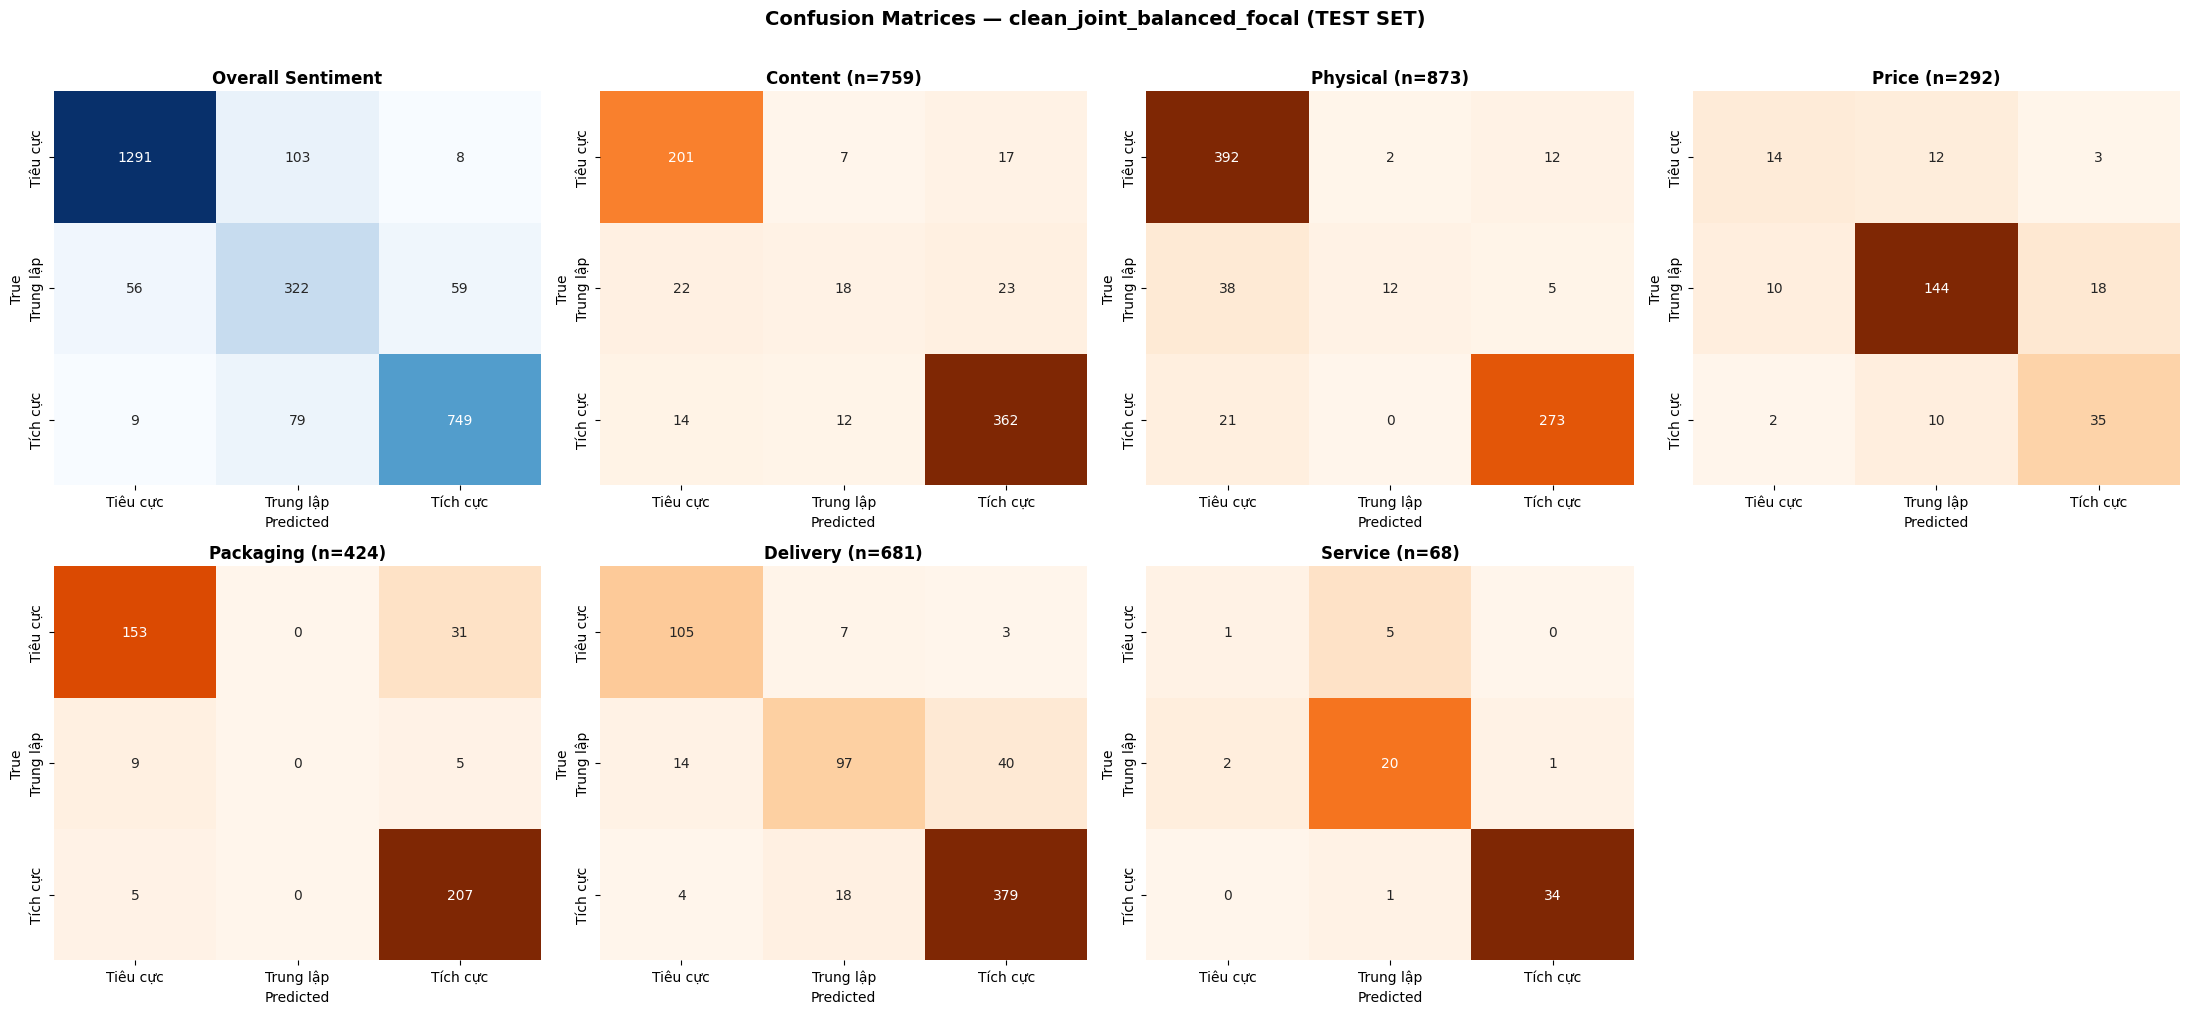

In [34]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()
NAMES = ['Tiêu cực', 'Trung lập', 'Tích cực']
ASP_DISPLAY = ['Content', 'Physical', 'Price', 'Packaging', 'Delivery', 'Service']

cm_sent = confusion_matrix(true_sent, pred_sent, labels=[0,1,2])
sns.heatmap(cm_sent, annot=True, fmt='d', cmap='Blues',
            xticklabels=NAMES, yticklabels=NAMES, ax=axes[0], cbar=False)
axes[0].set_title('Overall Sentiment', fontweight='bold')
axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')

for j, (col, disp) in enumerate(zip(ASPECT_COLS, ASP_DISPLAY)):
    ax  = axes[j + 1]
    idx = ASPECT_COLS.index(col)
    tc  = true_asps[:, idx]; pc = pred_asps[:, idx]
    mask = tc != 3
    if not mask.any():
        ax.set_visible(False); continue
    cm_asp = confusion_matrix(tc[mask], pc[mask], labels=[0,1,2])
    sns.heatmap(cm_asp, annot=True, fmt='d', cmap='Oranges',
                xticklabels=NAMES, yticklabels=NAMES, ax=ax, cbar=False)
    ax.set_title(f'{disp} (n={mask.sum()})', fontweight='bold')
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')

if len(axes) > 7:
    axes[7].set_visible(False)

plt.suptitle(f'Confusion Matrices — {best_result["name"]} (TEST SET)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('confusion_matrix_test.png', dpi=150, bbox_inches='tight')
plt.show()


## 17. Lưu mô hình tốt nhất

lưu mô hình và tokenizer tốt nhất ra thư mục final_model.

In [35]:
final_dir = Path('./absa_results') / f'final_model_{best_result["name"]}'
final_dir.mkdir(parents=True, exist_ok=True)
best_model.save_pretrained(final_dir)
best_tokenizer.save_pretrained(final_dir)
print('Saved final model to:', final_dir)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved final model to: absa_results/final_model_clean_joint_balanced_focal


## 18. Demo Inference

hàm inference cho một review đơn lẽ với mô hình đã train.

In [36]:
def predict_single(text: str, model, tokenizer, device, threshold: float = 0.5) -> dict:
    model.eval()
    enc = tokenizer(text, padding='max_length', truncation=True,
                    max_length=MAX_LENGTH, return_tensors='pt')
    enc = {k: v.to(device) for k, v in enc.items()}
    with torch.no_grad():
        logits = model(**enc).logits
    sent_logits, pres_logits, asp_sent_logits = parse_logits(logits)
    sent_probs  = F.softmax(sent_logits[0], dim=-1).cpu()
    pres_probs  = F.softmax(pres_logits[0], dim=-1).cpu()
    asp_probs   = F.softmax(asp_sent_logits[0], dim=-1).cpu()
    result = {
        'text': text,
        'sentiment': SENTIMENT_LABELS[sent_probs.argmax().item()],
        'sentiment_probs': {SENTIMENT_LABELS[i]: round(p.item(), 3) for i, p in enumerate(sent_probs)},
        'aspects': {},
    }
    for i, col in enumerate(ASPECT_COLS):
        p_present = pres_probs[i, 1].item()
        if p_present >= threshold:
            pred  = asp_probs[i].argmax().item()
            label = SENTIMENT_LABELS[pred]
            conf  = round(asp_probs[i, pred].item(), 3)
        else:
            label = 'Không nhắc đến'
            conf  = round(1 - p_present, 3)
        result['aspects'][col] = {'label': label, 'p_present': round(p_present, 3), 'confidence': conf}
    return result

def print_prediction(r: dict):
    print(f"\n📝 '{r['text'][:80]}'")
    print(f"   Sentiment: {r['sentiment']}  {r['sentiment_probs']}")
    print(f"   {'Aspect':<14} {'Label':<18} {'P(present)':<12} Conf")
    print('   ' + '-'*54)
    for col, v in r['aspects'].items():
        name = col.replace('as_', '')
        print(f"   {name:<14} {v['label']:<18} {v['p_present']:<12.3f} {v['confidence']:.3f}")

DEMO_TEXTS = [
    'Sách đẹp, in rõ ràng, giao hàng nhanh, đóng gói cẩn thận, giá hợp lý lắm!',
    'Sách bị nhàu nát khi nhận, bìa rách góc, liên hệ shop không phản hồi.',
    'Sách bình thường, không có gì đặc biệt, nội dung tạm được.',
    'Giá hơi cao so với chất lượng thật sự của cuốn sách này.',
    'Nội dung sách rất hay, nhưng ship lâu quá, mất gần 2 tuần mới nhận được.',
]
for text in DEMO_TEXTS:
    print_prediction(predict_single(text, best_model, best_tokenizer, device))



📝 'Sách đẹp, in rõ ràng, giao hàng nhanh, đóng gói cẩn thận, giá hợp lý lắm!'
   Sentiment: Tích cực  {'Tiêu cực': 0.066, 'Trung lập': 0.111, 'Tích cực': 0.823}
   Aspect         Label              P(present)   Conf
   ------------------------------------------------------
   content        Không nhắc đến     0.462        0.538
   physical       Tích cực           0.845        0.768
   price          Tích cực           0.838        0.722
   packaging      Tích cực           0.912        0.730
   delivery       Tích cực           0.903        0.727
   service        Không nhắc đến     0.481        0.519

📝 'Sách bị nhàu nát khi nhận, bìa rách góc, liên hệ shop không phản hồi.'
   Sentiment: Tiêu cực  {'Tiêu cực': 0.914, 'Trung lập': 0.056, 'Tích cực': 0.03}
   Aspect         Label              P(present)   Conf
   ------------------------------------------------------
   content        Không nhắc đến     0.286        0.714
   physical       Tiêu cực           0.872        0.787
   pric